In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Set plotting style
plt.style.use('ggplot')
sns.set_palette("viridis")

In [2]:
books = pd.read_csv('books.csv',low_memory=False)
users = pd.read_csv('users.csv')
ratings = pd.read_csv('ratings.csv')

In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
books['Image-URL-S'] = books['Image-URL-S'].str.replace('http://', 'https://')
books['Image-URL-M'] = books['Image-URL-M'].str.replace('http://', 'https://')
books['Image-URL-L'] = books['Image-URL-L'].str.replace('http://', 'https://')

In [5]:
books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,https://images.amazon.com/images/P/0195153448....,https://images.amazon.com/images/P/0195153448....,https://images.amazon.com/images/P/0195153448....
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,https://images.amazon.com/images/P/0002005018....,https://images.amazon.com/images/P/0002005018....,https://images.amazon.com/images/P/0002005018....
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,https://images.amazon.com/images/P/0060973129....,https://images.amazon.com/images/P/0060973129....,https://images.amazon.com/images/P/0060973129....
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,https://images.amazon.com/images/P/0374157065....,https://images.amazon.com/images/P/0374157065....,https://images.amazon.com/images/P/0374157065....
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,https://images.amazon.com/images/P/0393045218....,https://images.amazon.com/images/P/0393045218....,https://images.amazon.com/images/P/0393045218....
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),https://images.amazon.com/images/P/0440400988....,https://images.amazon.com/images/P/0440400988....,https://images.amazon.com/images/P/0440400988....
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,https://images.amazon.com/images/P/0525447644....,https://images.amazon.com/images/P/0525447644....,https://images.amazon.com/images/P/0525447644....
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,https://images.amazon.com/images/P/006008667X....,https://images.amazon.com/images/P/006008667X....,https://images.amazon.com/images/P/006008667X....
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,https://images.amazon.com/images/P/0192126040....,https://images.amazon.com/images/P/0192126040....,https://images.amazon.com/images/P/0192126040....


In [6]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [7]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [9]:
books.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [10]:
users.isna().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [11]:
ratings.isna().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [12]:
books.duplicated().sum()

np.int64(0)

In [13]:
ratings.duplicated().sum()

np.int64(0)

In [14]:
users.duplicated().sum()

np.int64(0)

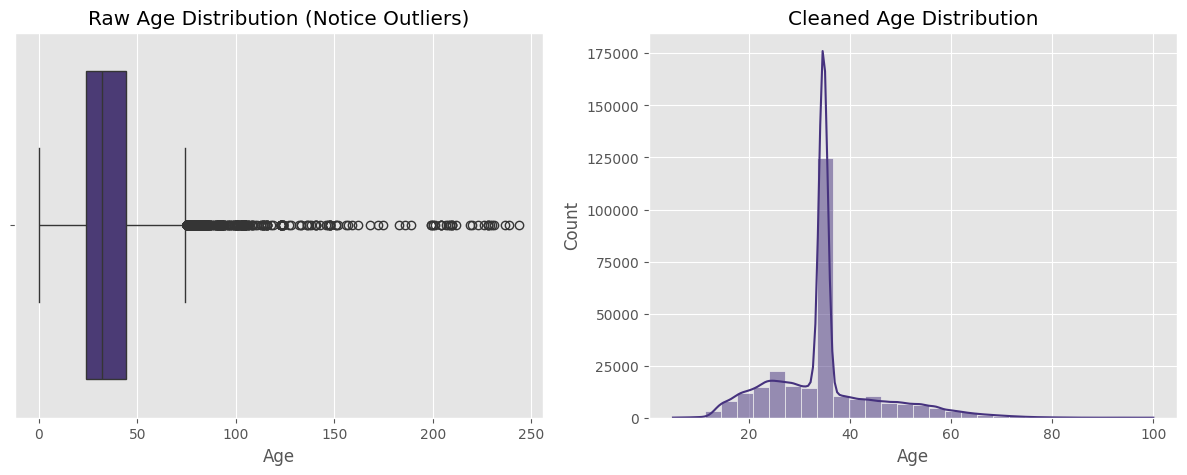

In [15]:
# The 'Age' column in Users usually has massive outliers. Let's see them:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot raw ages
sns.boxplot(x=users['Age'], ax=ax1)
ax1.set_title('Raw Age Distribution (Notice Outliers)')

# Clean up Age: Realistically, readers are between 5 and 100 years old
users.loc[(users.Age > 100) | (users.Age < 5), 'Age'] = np.nan
users['Age'] = users['Age'].fillna(users['Age'].mean())

# Plot cleaned ages
sns.histplot(users['Age'], bins=30, kde=True, ax=ax2)
ax2.set_title('Cleaned Age Distribution')
plt.show()


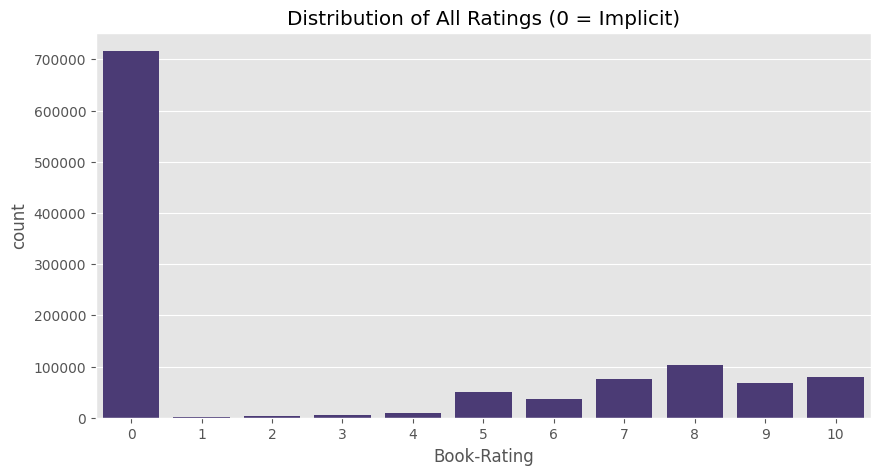

In [16]:
# In this dataset, a rating of 0 is usually an "Implicit" rating (interacted with, but didn't rate)
# Ratings 1-10 are "Explicit" ratings.

plt.figure(figsize=(10, 5))
sns.countplot(data=ratings, x='Book-Rating')
plt.title('Distribution of All Ratings (0 = Implicit)')
plt.show()

# Let's filter out explicit ratings to see how actual reviewers scored books
# explicit_ratings = ratings[ratings['Book-Rating'] != 0]

# plt.figure(figsize=(10, 5))
# sns.countplot(data=explicit_ratings, x='Book-Rating')
# plt.title('Distribution of Explicit Ratings (1-10)')
# plt.show()


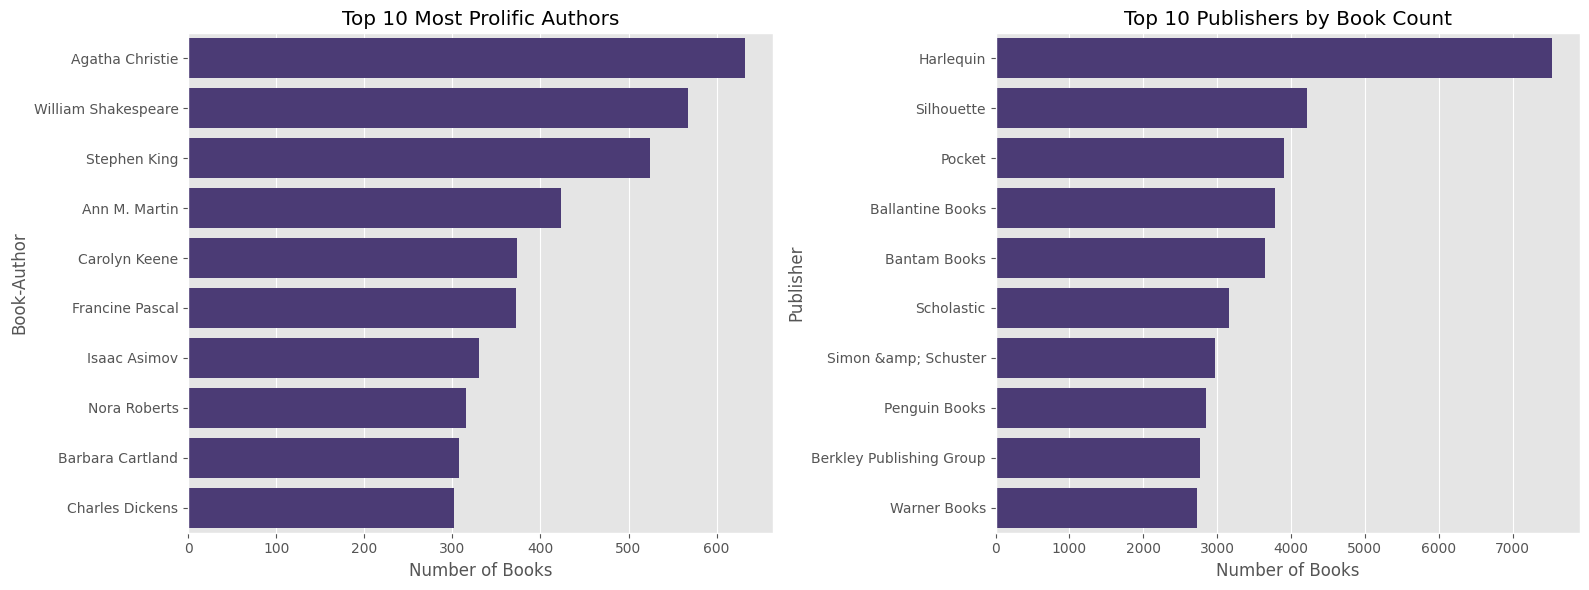

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Authors by number of books written
top_authors = books['Book-Author'].value_counts().head(10)
sns.barplot(x=top_authors.values, y=top_authors.index, ax=ax1)
ax1.set_title('Top 10 Most Prolific Authors')
ax1.set_xlabel('Number of Books')

# Top 10 Publishers
top_publishers = books['Publisher'].value_counts().head(10)
sns.barplot(x=top_publishers.values, y=top_publishers.index, ax=ax2)
ax2.set_title('Top 10 Publishers by Book Count')
ax2.set_xlabel('Number of Books')

plt.tight_layout()
plt.show()


## Popularity Based Recommendation System

In [18]:
ratings_with_name = ratings.merge(books, on='ISBN')

In [19]:
ratings_with_name.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,https://images.amazon.com/images/P/034545104X....,https://images.amazon.com/images/P/034545104X....,https://images.amazon.com/images/P/034545104X....
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,https://images.amazon.com/images/P/0155061224....,https://images.amazon.com/images/P/0155061224....,https://images.amazon.com/images/P/0155061224....
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,https://images.amazon.com/images/P/0446520802....,https://images.amazon.com/images/P/0446520802....,https://images.amazon.com/images/P/0446520802....
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,https://images.amazon.com/images/P/052165615X....,https://images.amazon.com/images/P/052165615X....,https://images.amazon.com/images/P/052165615X....
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,https://images.amazon.com/images/P/0521795028....,https://images.amazon.com/images/P/0521795028....,https://images.amazon.com/images/P/0521795028....


In [20]:
num_rating_df = ratings_with_name.groupby('Book-Title')['Book-Rating'].count().reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [21]:
avg_rating_df = ratings_with_name.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_rating_df.rename(columns={'Book-Rating':'avg_ratings'},inplace=True)
avg_rating_df

,Book-Title,avg_ratings
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [22]:
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df

,Book-Title,num_ratings,avg_ratings
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [23]:
popular_df.shape

(241071, 3)

In [24]:
popular_df = popular_df[popular_df['num_ratings'] >= 250].sort_values('avg_ratings',ascending=False).head(50)
popular_df.head()

,Book-Title,num_ratings,avg_ratings
80434,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
80422,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
80441,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
80426,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
80414,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453


In [25]:
popular_df.shape

(50, 3)

In [26]:
popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title').shape

(50, 10)

In [27]:
popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_ratings']]
popular_df

,Book-Title,Book-Author,Image-URL-M,num_ratings,avg_ratings
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,https://images.amazon.com/images/P/0439136350....,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,https://images.amazon.com/images/P/0439139597....,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,https://images.amazon.com/images/P/0590353403....,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,https://images.amazon.com/images/P/043935806X....,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,https://images.amazon.com/images/P/0439064872....,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,https://images.amazon.com/images/P/0345339681....,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,https://images.amazon.com/images/P/0345339703....,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,https://images.amazon.com/images/P/059035342X....,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,https://images.amazon.com/images/P/0345339711....,260,4.880769
39,To Kill a Mockingbird,Harper Lee,https://images.amazon.com/images/P/0446310786....,510,4.700000


## Collaborative Filtering Based Recommender System

In [28]:
x = ratings_with_name.groupby('User-ID')['Book-Rating'].count() > 200
most_rated_users = x[x].index

In [29]:
most_rated_users.shape

(811,)

In [30]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(most_rated_users)]
filtered_rating

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,https://images.amazon.com/images/P/002542730X....,https://images.amazon.com/images/P/002542730X....,https://images.amazon.com/images/P/002542730X....
1151,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,https://images.amazon.com/images/P/0026217457....,https://images.amazon.com/images/P/0026217457....,https://images.amazon.com/images/P/0026217457....
1152,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,https://images.amazon.com/images/P/003008685X....,https://images.amazon.com/images/P/003008685X....,https://images.amazon.com/images/P/003008685X....
1153,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,https://images.amazon.com/images/P/0030615321....,https://images.amazon.com/images/P/0030615321....,https://images.amazon.com/images/P/0030615321....
1154,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,https://images.amazon.com/images/P/0060002050....,https://images.amazon.com/images/P/0060002050....,https://images.amazon.com/images/P/0060002050....
...,...,...,...,...,...,...,...,...,...,...
1029357,275970,1931868123,0,There's a Porcupine in My Outhouse: Misadventu...,Mike Tougias,2002,Capital Books (VA),https://images.amazon.com/images/P/1931868123....,https://images.amazon.com/images/P/1931868123....,https://images.amazon.com/images/P/1931868123....
1029358,275970,3411086211,10,Die Biene.,Sybil GrÃ?Â¤fin SchÃ?Â¶nfeldt,1993,"Bibliographisches Institut, Mannheim",https://images.amazon.com/images/P/3411086211....,https://images.amazon.com/images/P/3411086211....,https://images.amazon.com/images/P/3411086211....
1029359,275970,3829021860,0,The Penis Book,Joseph Cohen,1999,Konemann,https://images.amazon.com/images/P/3829021860....,https://images.amazon.com/images/P/3829021860....,https://images.amazon.com/images/P/3829021860....
1029360,275970,4770019572,0,Musashi,Eiji Yoshikawa,1995,Kodansha International (JPN),https://images.amazon.com/images/P/4770019572....,https://images.amazon.com/images/P/4770019572....,https://images.amazon.com/images/P/4770019572....


In [31]:
y = filtered_rating.groupby('Book-Title')['Book-Rating'].count() > 50
famous_books = y[y].index
famous_books

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='Book-Title', length=679)

In [32]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]
final_ratings

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,https://images.amazon.com/images/P/002542730X....,https://images.amazon.com/images/P/002542730X....,https://images.amazon.com/images/P/002542730X....
1163,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,https://images.amazon.com/images/P/0060930535....,https://images.amazon.com/images/P/0060930535....,https://images.amazon.com/images/P/0060930535....
1165,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,https://images.amazon.com/images/P/0060934417....,https://images.amazon.com/images/P/0060934417....,https://images.amazon.com/images/P/0060934417....
1168,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,https://images.amazon.com/images/P/0061009059....,https://images.amazon.com/images/P/0061009059....,https://images.amazon.com/images/P/0061009059....
1174,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,https://images.amazon.com/images/P/006440188X....,https://images.amazon.com/images/P/006440188X....,https://images.amazon.com/images/P/006440188X....
...,...,...,...,...,...,...,...,...,...,...
1029196,275970,1400031354,0,Tears of the Giraffe (No.1 Ladies Detective Ag...,Alexander McCall Smith,2002,Anchor,https://images.amazon.com/images/P/1400031354....,https://images.amazon.com/images/P/1400031354....,https://images.amazon.com/images/P/1400031354....
1029197,275970,1400031362,0,Morality for Beautiful Girls (No.1 Ladies Dete...,Alexander McCall Smith,2002,Anchor,https://images.amazon.com/images/P/1400031362....,https://images.amazon.com/images/P/1400031362....,https://images.amazon.com/images/P/1400031362....
1029270,275970,1573229725,0,Fingersmith,Sarah Waters,2002,Riverhead Books,https://images.amazon.com/images/P/1573229725....,https://images.amazon.com/images/P/1573229725....,https://images.amazon.com/images/P/1573229725....
1029309,275970,1586210661,9,Me Talk Pretty One Day,David Sedaris,2001,Time Warner Audio Major,https://images.amazon.com/images/P/1586210661....,https://images.amazon.com/images/P/1586210661....,https://images.amazon.com/images/P/1586210661....


In [33]:
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1st to Die: A Novel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd Chance,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
4 Blondes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A Bend in the Road,0.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,9.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
You Belong To Me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [34]:
pt.fillna(0,inplace=True)
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
from sklearn.metrics.pairwise import cosine_similarity

In [36]:
similarity_scores = cosine_similarity(pt)
similarity_scores

array([[1.        , 0.10255025, 0.01220856, ..., 0.12110367, 0.07347567,
        0.04316046],
       [0.10255025, 1.        , 0.2364573 , ..., 0.07446129, 0.16773875,
        0.14263397],
       [0.01220856, 0.2364573 , 1.        , ..., 0.04558758, 0.04938579,
        0.10796119],
       ...,
       [0.12110367, 0.07446129, 0.04558758, ..., 1.        , 0.07085128,
        0.0196177 ],
       [0.07347567, 0.16773875, 0.04938579, ..., 0.07085128, 1.        ,
        0.10602962],
       [0.04316046, 0.14263397, 0.10796119, ..., 0.0196177 , 0.10602962,
        1.        ]], shape=(679, 679))

In [37]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:6]
    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == pt.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
        
        data.append(item)

    return data

In [38]:
recommend('Message in a Bottle')

[['Nights in Rodanthe',
  'Nicholas Sparks',
  'https://images.amazon.com/images/P/0446531332.01.MZZZZZZZ.jpg'],
 ['The Mulberry Tree',
  'Jude Deveraux',
  'https://images.amazon.com/images/P/0743437640.01.MZZZZZZZ.jpg'],
 ['A Walk to Remember',
  'Nicholas Sparks',
  'https://images.amazon.com/images/P/0446608955.01.MZZZZZZZ.jpg'],
 ["River's End",
  'Nora Roberts',
  'https://images.amazon.com/images/P/0515127833.01.MZZZZZZZ.jpg'],
 ['Nightmares &amp; Dreamscapes',
  'Stephen King',
  'https://images.amazon.com/images/P/0451180232.01.MZZZZZZZ.jpg']]

In [39]:
import joblib
joblib.dump(popular_df,open('popular.joblib','wb'))

In [40]:
books.drop_duplicates('Book-Title')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,https://images.amazon.com/images/P/0195153448....,https://images.amazon.com/images/P/0195153448....,https://images.amazon.com/images/P/0195153448....
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,https://images.amazon.com/images/P/0002005018....,https://images.amazon.com/images/P/0002005018....,https://images.amazon.com/images/P/0002005018....
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,https://images.amazon.com/images/P/0060973129....,https://images.amazon.com/images/P/0060973129....,https://images.amazon.com/images/P/0060973129....
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,https://images.amazon.com/images/P/0374157065....,https://images.amazon.com/images/P/0374157065....,https://images.amazon.com/images/P/0374157065....
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,https://images.amazon.com/images/P/0393045218....,https://images.amazon.com/images/P/0393045218....,https://images.amazon.com/images/P/0393045218....
...,...,...,...,...,...,...,...,...
271354,0449906736,Flashpoints: Promise and Peril in a New World,Robin Wright,1993,Ballantine Books,https://images.amazon.com/images/P/0449906736....,https://images.amazon.com/images/P/0449906736....,https://images.amazon.com/images/P/0449906736....
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,https://images.amazon.com/images/P/0525447644....,https://images.amazon.com/images/P/0525447644....,https://images.amazon.com/images/P/0525447644....
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,https://images.amazon.com/images/P/006008667X....,https://images.amazon.com/images/P/006008667X....,https://images.amazon.com/images/P/006008667X....
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,https://images.amazon.com/images/P/0192126040....,https://images.amazon.com/images/P/0192126040....,https://images.amazon.com/images/P/0192126040....


In [41]:
books.to_csv('Modified Books.csv',index=False)

In [42]:
joblib.dump(pt,open('pt.joblib','wb'))
# joblib.dump(books,open('books.joblib','wb'))
joblib.dump(similarity_scores,open('similarity_scores.joblib','wb'))